In [1]:
import sys
sys.path.append('/machfs/swhite/pyml/pyacal-test')
import pyacal
import os
import warnings
import at
import matplotlib.pyplot as plt
import time
import numpy
plt.rcParams['figure.figsize'] = [20, 10]
from pyacal.experiments.disp_chrom import DispChrom

In [2]:
pyacal.set_facility('esrf')
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    path = '/operation/beamdyn/matlab/optics/sr/theory/'
    ring = at.load_lattice('./betamodel.mat', use='betamodel')
pyacal.set_model('EBS', ring)

In [3]:
dispchrom = DispChrom(accelerator='EBS', isonline=True)

In [4]:
dispchrom.params.max_delta_freq = +100  # [Hz]
dispchrom.params.min_delta_freq = -100  # [Hz]
dispchrom.params.wait_tune = 10 # [s]
dispchrom.params.meas_nrsteps = 11
print(dispchrom.params)

max_delta_freq [Hz]      =   100.000  
min_delta_freq [Hz]      =  -100.000  
meas_nrsteps             =        11  
wait_tune [s]            =    10.000  
sofb_nrpoints            =        10  



In [25]:
dispchrom._run()

delta frequency: -100.0 Hz
(Spec. Analy.) dtune x: 0.036713766899624634 y: 0.027191991943113503

delta frequency: -80.0 Hz
(Spec. Analy.) dtune x: 0.02624591814935759 y: 0.024719992675557745

delta frequency: -60.0 Hz
(Spec. Analy.) dtune x: 0.018951994384594273 y: 0.016022217474898515

delta frequency: -40.0 Hz
(Spec. Analy.) dtune x: 0.014343699453718689 y: 0.010589922788171058

delta frequency: -20.0 Hz
(Spec. Analy.) dtune x: 0.004333628345591617 y: 0.005462813196203509

delta frequency: 0.0 Hz
(Spec. Analy.) dtune x: -9.155552842798897e-05 y: 0.0003967406231879522

delta frequency: 20.0 Hz
(Spec. Analy.) dtune x: -0.007141331217383334 y: -0.004791405987731534

delta frequency: 40.0 Hz
(Spec. Analy.) dtune x: -0.014038514358958698 y: -0.009796441541795098

delta frequency: 60.0 Hz
(Spec. Analy.) dtune x: -0.020477919858394117 y: -0.0174260689107944

delta frequency: 80.0 Hz
(Spec. Analy.) dtune x: -0.02728354747154149 y: -0.016418958098086467

delta frequency: 100.0 Hz
(Spec. Analy

dict_keys(['freq0', 'tunex0', 'tuney0', 'orbx0', 'orby0', 'freq', 'tunex', 'tuney', 'orbx', 'orby'])


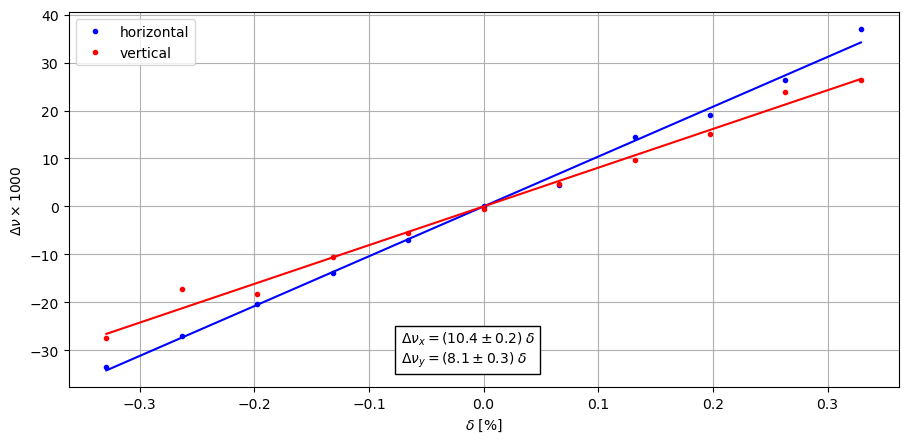

In [30]:
print(dispchrom.data.keys())
dispchrom.mom_compact = ring.mcf
dispchrom.process_data()
#dispchrom.make_figure_disp()
dispchrom.make_figure_chrom()

In [11]:
with open('disp_chrom.pkl', 'wb') as f:
    pickle.dump(dispchrom.data, f)

/machfs/swhite/pyml/pyacal-test/pyacal/experiments/disp_chrom.py:291: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


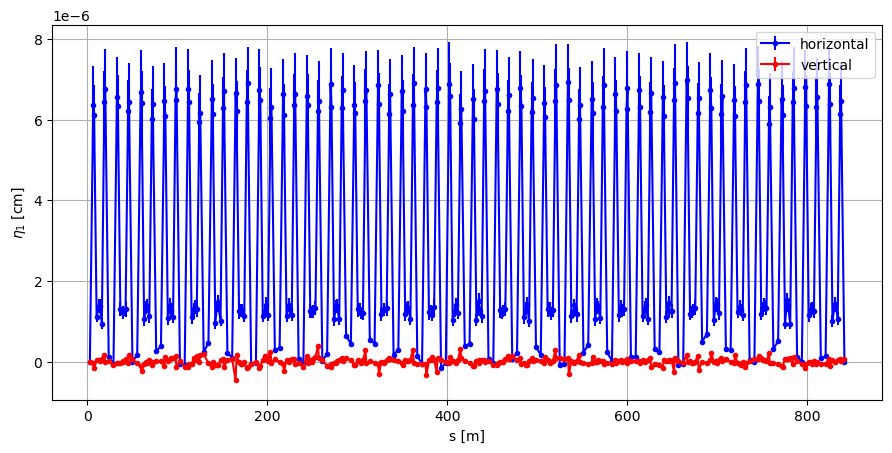

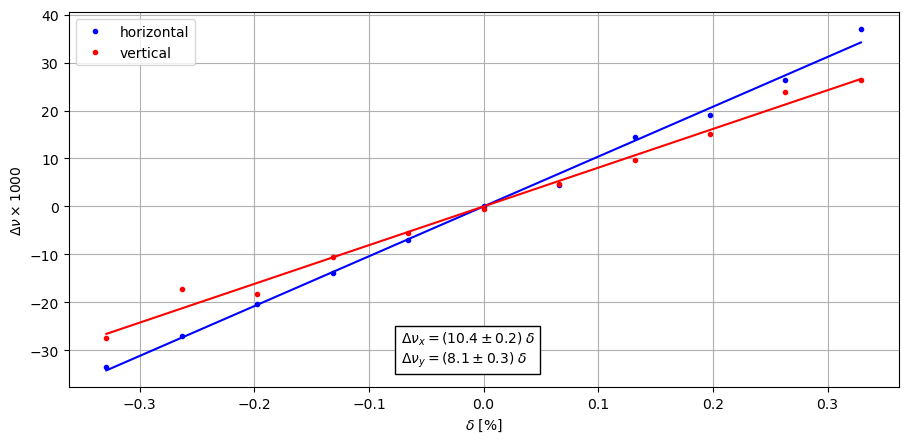

In [10]:
dataf = open('disp_chrom.pkl', 'rb')
data = pickle.load(dataf)
dispchrom.data = data
dispchrom.mom_compact = ring.mcf
dispchrom.process_data()
dispchrom.make_figure_disp()
dispchrom.make_figure_chrom()